In [1]:
import radiate as rd
import polars as pl
from IPython.display import display, HTML

rd.random.seed(67123)

In [2]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])

In [3]:
collector = rd.MetricCollector()

best_score = rd.select("scores").min()

sma_5 = best_score.rolling(5).mean()
sma_10 = best_score.rolling(10).mean()
sma_20 = best_score.rolling(20).mean()

sma_10_stddev = best_score.rolling(10).stddev()

# plateau = rd.select("scores").min().rolling(10).stddev() <= 0.001

# mutation_rate = rd.when(plateau).then(0.12).otherwise(0.06)
# crossover_rate = rd.when(plateau).then(0.03).otherwise(0.06)


diversity = rd.select("rate.diversity").rolling(10).mean()
progress = ((sma_5 - sma_20) / (sma_20 + 1e-6)).clamp(0.0, 1.0)
score_stddev = rd.select("scores").min().rolling(10).stddev()
slope = rd.select("scores.best").rolling(10).slope()
slope_div = rd.select("rate.diversity").rolling(10).slope()

pressure = (
    (
        rd.lit(0.5)
        * (
            (rd.lit(0.02) - progress)
            + rd.lit(0.8) * (rd.lit(0.7) - diversity)
            + rd.lit(0.4) * (-slope_div)
        )
    )
    # .rolling(10)
    # .mean()
    .clamp(0.0, 1.0)
)

crossover_rate = (
    rd.lit(0.05)
    * (
        rd.lit(1.0)
        + rd.lit(0.5) * diversity
        + rd.lit(0.3) * progress
        - rd.lit(0.3) * (-slope_div).clamp(0.0, 0.5)
    )
).clamp(0.01, 0.12)

norm_slope = (slope / (score_stddev + rd.lit(1e-6))).clamp(-1.0, 1.0)

progress = ((sma_20 - sma_5) / (sma_20 + rd.lit(1e-6))).clamp(0.0, 1.0)
diversity = rd.select("rate.diversity").rolling(10).mean().clamp(0.0, 1.0)
flatness = (rd.lit(0.001) - abs(slope)).clamp(0.0, 1.0)
div_collapse = (rd.lit(0.0) - slope_div).clamp(0.0, 1.0)
low_volatility = (rd.lit(0.05) - score_stddev).clamp(0.0, 1.0)

w0, w1, w2, w3, w4, w5 = 0.02, 0.5, 0.4, 0.4, 0.4, 0.4

pressure = (
    rd.lit(w0)
    + rd.lit(w1) * (rd.lit(0.2) - progress)
    + rd.lit(w2) * (rd.lit(0.7) - diversity)
    + rd.lit(w3) * div_collapse
    + rd.lit(w4) * flatness
    + rd.lit(w5) * (rd.lit(0.05) - low_volatility)
).clamp(0.0, 1.0)

engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(collector)
    .metrics(
        slope=norm_slope,
        # div=diversity,
        # slope_div=slope_div,
        score_stddev=score_stddev,
        pressure=pressure,
        # sma_5=explore_scaled_with_diversity,
        # sma_10=needs_to_expore_signal,
        # sma_20=diversity,
        # progress=progress,
    )
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.score(0.001), rd.Limit.generations(1000))
)

result = engine.run(log=True)

PyEngineInput { 
	component: TournamentSelector, 
	input_type: OffspringSelector, 
	allowed_genes: {TreeNode, Bit, Float, Char, GraphNode, Int, Permutation}, 
	rate: None, 
	args: {
		k: PyAnyObject { inner: Py(0x1044977c0) }
} 
}
PyEngineInput { 
	component: RouletteSelector, 
	input_type: SurvivorSelector, 
	allowed_genes: {TreeNode, Float, Int, Bit, Permutation, Char, GraphNode}, 
	rate: None, 
	args: {} 
}
PyEngineInput { 
	component: PopulationSize, 
	input_type: PopulationSize, 
	allowed_genes: {Bit, Float, Int, Char, GraphNode, TreeNode, Permutation}, 
	rate: None, 
	args: {
		size: PyAnyObject { inner: Py(0x1044983e0) }
} 
}
PyEngineInput { 
	component: OffspringFraction, 
	input_type: OffspringFraction, 
	allowed_genes: {Char, Bit, TreeNode, Int, Permutation, Float, GraphNode}, 
	rate: None, 
	args: {
		fraction: PyAnyObject { inner: Py(0x10a0876f0) }
} 
}
PyEngineInput { 
	component: MaxPhenotypeAge, 
	input_type: MaxPhenotypeAge, 
	allowed_genes: {GraphNode, Int, Bit, TreeNo

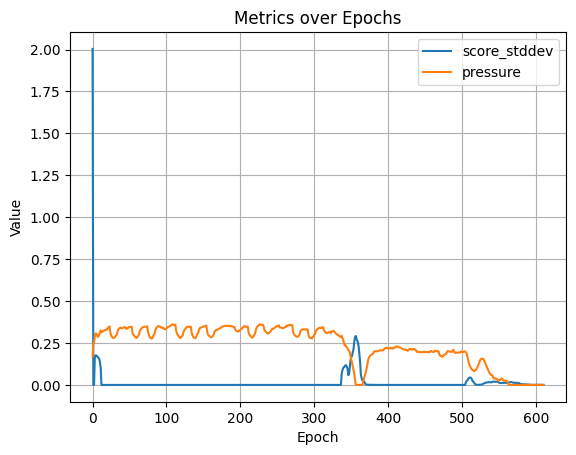

In [4]:
collector.plot(
    # "sma_5",
    # "sma_10",
    # "sma_20",
    # "progress",
    # "slope",
    # "div",
    "score_stddev",
    # "slope",
    # "slope_div",
    "pressure",
    # "scores.best",
    # "crossover.graph.rate",
    # "mutate.operation.rate",
    # "crossover.graph.rate",
)

In [5]:
eval_results = result.value().eval(inputs)
accuracy = rd.accuracy(result.value(), inputs, answers, loss=rd.MSE)

# print(result)
# print(result.metrics().dashboard())
# print(accuracy)

score_stddev


Expr(Aggregate(
    AggExpr {
        child: Selector(
            Field(
                StrOwned(
                    "scores",
                ),
                Field {
                    name: "min",
                    dtype: Float32,
                },
            ),
        ),
        rollup: StdDev,
        buffer: Some(
            WindowBuffer {
                capacity: 10,
                values: [],
            },
        ),
    },
))

In [6]:
df = collector.to_polars(lazy=False)
df


name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,version,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""new.children""",63.0,63.0,63.0,0.0,0.0,NaN,63.0,63.0,1,null,null,null,null,null,null,0,1,"[""derived"", ""statistic""]"
"""score.volatility""",0.051598,0.051598,0.051598,0.0,0.0,NaN,0.051598,0.051598,1,null,null,null,null,null,null,0,1,"[""derived"", ""statistic"", ""score""]"
"""score_stddev""",2.003778,2.003778,2.003778,0.0,0.0,NaN,2.003778,2.003778,1,null,null,null,null,null,null,0,1,"[""statistic"", ""score"", ""expr""]"
"""rate.carryover""",0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1,null,null,null,null,null,null,0,1,"[""derived"", ""statistic"", ""rate""]"
"""scores.best""",2.003778,2.003778,2.003778,0.0,0.0,NaN,2.003778,2.003778,1,null,null,null,null,null,null,0,1,"[""statistic"", ""score""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""step.audit.time""",0.000012,0.006797,0.000011,0.000009,8.0116e-11,0.0,0.000007,0.000197,611,6797µs,11µs,8µs,7µs,197µs,0µs,610,1,"[""time"", ""step""]"
"""step.recombine.time""",0.000102,0.035926,0.000059,0.000026,6.8604e-10,0.0,0.000031,0.00018,611,35926µs,58µs,26µs,30µs,179µs,0µs,610,1,"[""time"", ""step""]"
"""index""",611.0,611.0,611.0,0.0,0.0,NaN,611.0,611.0,1,null,null,null,null,null,null,0,0,"[""statistic""]"


In [7]:
filtered = (
    df.filter(pl.col("name") == "score.improvement")
    .select("version")
    .unique()
    .sort("version")
)
filtered

version
i64
0
3
326
327
328
…
603
605
607


In [8]:
display(HTML(filtered._repr_html_()))

version
i64
0
3
326
327
328
…
603
605
607
